# Mantenimiento Predictivo Industrial con Aprendizaje por Refuerzo

**Trabajo Final Grupal — Aprendizaje por Refuerzo**

**Integrantes:** César Nelson Abarca Araujo · Iván Fernando Vega Salazar · Santiago Paúl Guallichico Ati

**Reparto de trabajo:** César — elaboración del informe y validación de resultados · Santiago — entrenamiento y simulación · Iván — creación del video explicativo

## Objetivo / Problemática

En la gestión de activos e ingeniería industrial, la transición de un mantenimiento reactivo
a un mantenimiento predictivo es clave para maximizar la rentabilidad y evitar paradas de
línea costosas. Este proyecto diseña e implementa una planta industrial simulada (bajo el
estándar Gymnasium) con 4 máquinas operando en paralelo, cada una sujeta a un desgaste
estocástico continuo. Se entrena un agente de Aprendizaje por Refuerzo (DQN) para decidir,
en tiempo real, el momento óptimo de intervenir con mantenimiento preventivo, y se compara
su desempeño contra una política tradicional de mantenimiento por calendario fijo.

**¿Por qué DQN?** El estado del entorno es un vector **continuo** (salud de cada máquina,
0-100%), por lo que un método tabular (Q-Learning, SARSA o Monte Carlo clásicos) exigiría
discretizar ese espacio, perdiendo precisión. DQN es, en esencia, Q-Learning (misma
actualización de Bellman, misma política ε-greedy) extendido con una red neuronal como
aproximador de funciones para manejar estados continuos — por eso se eligió sobre los
métodos tabulares vistos en clase.

## Este notebook integra:
1. El entorno de simulación (`MaintenanceEnv`)
2. El entrenamiento y evaluación del agente DQN 
3. La simulación de la política tradicional sin RL 
4. Una comparación directa de ambos enfoques


## 0. Instalación de dependencias

Ejecutar solo si falta algún paquete en el entorno.

In [60]:
# !pip install gymnasium stable-baselines3 pygame moviepy


In [61]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import RecordVideo, TimeLimit
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
import pygame


### Semilla de reproducibilidad

`MaintenanceEnv` genera el desgaste con `np.random.exponential(...)` / `np.random.uniform(...)`
— el generador **global** de NumPy, no el `self.np_random` que Gymnasium prepara al llamar
`env.reset(seed=...)`. Por eso pasar una semilla solo a `reset()` **no** hace reproducible el
entorno; hay que fijar la semilla global de NumPy explícitamente (y la del propio modelo DQN).
Sin esto, cada corrida de entrenamiento parte de una inicialización y una secuencia de
desgaste distintas, lo que puede producir políticas muy dispares entre una corrida y otra.

In [62]:
SEED = 42
np.random.seed(SEED)


## 1. Entorno de simulación: `MaintenanceEnv`

Entorno Gymnasium personalizado que simula el desgaste estocástico de 4 máquinas
industriales. El agente decide en cada paso si operar (0) o solicitar mantenimiento (1).

**Recompensas:**
- +10 por máquina en producción activa
- +20 por mantenimiento preventivo oportuno (salud entre 5% y 20%)
- −10 por mantenimiento innecesario (salud > 20%)
- −600 por avería (salud ≤ 5%, reparación forzada de emergencia)


In [63]:
class MaintenanceEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 6}

    def __init__(self, num_machines=4, render_mode=None):
        super().__init__()
        self.num_machines = num_machines
        self.render_mode = render_mode
        self.machine_names = ["MÁQUINA A", "MÁQUINA B", "MÁQUINA C", "MÁQUINA D"]

        self.observation_space = spaces.Box(
            low=0.0, high=100.0, shape=(num_machines,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(2)

        self.window = None
        self.clock = None
        self.canvas = None

        self.step_counter = 0
        self.total_preventive = 0
        self.total_corrective = 0
        self.operational_steps = 0
        self.cumulative_reward = 0.0
        self.history_log = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.random.uniform(85.0, 100.0, size=(self.num_machines,)).astype(np.float32)

        self.step_counter = 0
        self.total_preventive = 0
        self.total_corrective = 0
        self.operational_steps = 0
        self.cumulative_reward = 0.0
        self.history_log = ["[SISTEMA] Planta industrial lista..."]

        return self.state, {}

    def step(self, action):
        self.step_counter += 1
        reward = 0.0
        terminated = False

        # 1. DESGASTE ESTOCÁSTICO CONTINUO
        wear = np.random.exponential(scale=2.0, size=(self.num_machines,))
        self.state -= wear

        worst_idx = np.argmin(self.state)
        worst_name = self.machine_names[worst_idx]
        worst_health = self.state[worst_idx]

        # 2. ACCIÓN DEL AGENTE (MANTENIMIENTO PREVENTIVO EN ZONA DE ALERTA: 5% < H <= 20%)
        if action == 1:
            if 5.0 < worst_health <= 20.0:
                self.state[worst_idx] = 100.0
                reward += 20.0  # INCENTIVO POSITIVO: Se premia la prevención a tiempo
                self.total_preventive += 1

                log_entry = f"[{self.step_counter:03d}] MANT. PREVENTIVO: {worst_name} ({int(worst_health)}% -> 100%)"
                self._add_log(log_entry)
            elif worst_health > 20.0:
                # Intento de mantenimiento innecesario (>20%) -> Pequeña penalización suave
                reward -= 10.0

        # 3. EVALUACIÓN DE AVERÍAS Y MANTENIMIENTOS CORRECTIVOS (<= 5.0%)
        has_failure = False
        for i in range(self.num_machines):
            if self.state[i] <= 5.0:
                self.state[i] = 100.0     # Reparación de emergencia obligatoria
                reward -= 600.0           # SEVERA PENALIZACIÓN por permitir la avería
                self.total_corrective += 1
                has_failure = True

                log_entry = f"[{self.step_counter:03d}] ¡MANT. CORRECTIVO!: {self.machine_names[i]} averiada (<=5%)"
                self._add_log(log_entry)
            else:
                reward += 10.0  # Recompensa por producción continua

        if not has_failure:
            self.operational_steps += 1

        self.cumulative_reward += reward

        if self.render_mode is not None:
            self.render()

        return self.state, reward, terminated, False, {}

    def _add_log(self, text):
        self.history_log.append(text)
        if len(self.history_log) > 6:
            self.history_log.pop(0)

    def render(self):
        if not pygame.get_init():
            pygame.init()
        if not pygame.font.get_init():
            pygame.font.init()

        width, height = 1020, 560
        font_head = pygame.font.SysFont("Segoe UI", 18, bold=True)
        font_title = pygame.font.SysFont("Segoe UI", 13, bold=True)
        font_body = pygame.font.SysFont("Segoe UI", 11)
        font_kpi_val = pygame.font.SysFont("Segoe UI", 18, bold=True)

        if self.window is None and self.render_mode == "human":
            self.window = pygame.display.set_mode((width, height))
            self.clock = pygame.time.Clock()

        if self.canvas is None:
            self.canvas = pygame.Surface((width, height))

        BG_COLOR = (20, 24, 33)
        PANEL_BG = (30, 36, 50)
        PANEL_BORDER = (45, 55, 75)
        TEXT_MAIN = (240, 244, 250)
        TEXT_MUTED = (140, 150, 170)
        COLOR_GREEN = (46, 204, 113)
        COLOR_YELLOW = (241, 196, 15)
        COLOR_ORANGE = (230, 126, 34)
        COLOR_RED = (231, 76, 60)
        COLOR_BLUE = (52, 152, 219)

        self.canvas.fill(BG_COLOR)

        # 1. ENCABEZADO
        pygame.draw.rect(self.canvas, PANEL_BG, (15, 15, 990, 50), border_radius=8)
        pygame.draw.rect(self.canvas, PANEL_BORDER, (15, 15, 990, 50), width=1, border_radius=8)

        lbl_title = font_head.render("SISTEMA DE MANTENIMIENTO PREDICTIVO — AGENTE RL (DQN)", True, TEXT_MAIN)
        lbl_step = font_title.render(f"PASO DE SIMULACIÓN: {self.step_counter:04d}", True, COLOR_BLUE)
        self.canvas.blit(lbl_title, (25, 25))
        self.canvas.blit(lbl_step, (760, 27))

        # 2. SECCIÓN MÁQUINAS EN TIEMPO REAL
        pygame.draw.rect(self.canvas, PANEL_BG, (15, 75, 620, 315), border_radius=8)
        pygame.draw.rect(self.canvas, PANEL_BORDER, (15, 75, 620, 315), width=1, border_radius=8)

        lbl_sec1 = font_title.render("ESTADO OPERATIVO DE MÁQUINAS", True, TEXT_MUTED)
        self.canvas.blit(lbl_sec1, (30, 85))

        for i in range(self.num_machines):
            health = max(0.0, float(self.state[i]))
            x_pos = 35 + i * 145

            if health > 30.0:
                bar_color, status_txt = COLOR_GREEN, "ÓPTIMO"
            elif health > 15.0:
                bar_color, status_txt = COLOR_YELLOW, "PREVENTIVO"
            elif health > 5.0:
                bar_color, status_txt = COLOR_ORANGE, "ALERTA"
            else:
                bar_color, status_txt = COLOR_RED, "CRÍTICO"

            txt_m_name = font_title.render(self.machine_names[i], True, TEXT_MAIN)
            self.canvas.blit(txt_m_name, (x_pos + 10, 110))

            pygame.draw.rect(self.canvas, (20, 25, 35), (x_pos, 135, 85, 180), border_radius=6)

            bar_h = int((health / 100.0) * 180)
            if bar_h > 0:
                pygame.draw.rect(self.canvas, bar_color, (x_pos, 135 + (180 - bar_h), 85, bar_h), border_radius=6)

            txt_pct = font_kpi_val.render(f"{int(health)}%", True, TEXT_MAIN)
            txt_st = font_body.render(status_txt, True, bar_color)
            self.canvas.blit(txt_pct, (x_pos + 22, 322))
            self.canvas.blit(txt_st, (x_pos + 15, 350))

        # 3. HISTORIAL Y MATRIZ DE RECOMPENSAS
        pygame.draw.rect(self.canvas, PANEL_BG, (645, 75, 360, 205), border_radius=8)
        pygame.draw.rect(self.canvas, PANEL_BORDER, (645, 75, 360, 205), width=1, border_radius=8)

        lbl_sec2 = font_title.render("HISTORIAL DE DECISIONES DE RL", True, TEXT_MUTED)
        self.canvas.blit(lbl_sec2, (660, 85))
        pygame.draw.line(self.canvas, PANEL_BORDER, (660, 105), (990, 105), 1)

        for idx, log in enumerate(self.history_log):
            if "CORRECTIVO" in log:
                color_line = COLOR_RED
            elif "PREVENTIVO" in log:
                color_line = COLOR_GREEN
            else:
                color_line = TEXT_MUTED

            txt_log = font_body.render(log, True, color_line)
            self.canvas.blit(txt_log, (660, 115 + idx * 24))

        # Matriz de Recompensas (Texto y colores sincronizados)
        pygame.draw.rect(self.canvas, PANEL_BG, (645, 290, 360, 100), border_radius=8)
        pygame.draw.rect(self.canvas, PANEL_BORDER, (645, 290, 360, 100), width=1, border_radius=8)

        lbl_rew_title = font_title.render("MATRIZ DE RECOMPENSAS (MDP)", True, TEXT_MUTED)
        self.canvas.blit(lbl_rew_title, (660, 298))
        pygame.draw.line(self.canvas, PANEL_BORDER, (660, 318), (990, 318), 1)

        r_prod = font_body.render("• Producción activa: +10 pts/máquina", True, COLOR_GREEN)
        r_prev = font_body.render("• Mant. Preventivo (5% < H <= 20%): +20 pts", True, COLOR_YELLOW)
        r_fail = font_body.render("• Mant. Correctivo (<=5%): -600 pts", True, COLOR_RED)

        self.canvas.blit(r_prod, (660, 326))
        self.canvas.blit(r_prev, (660, 346))
        self.canvas.blit(r_fail, (660, 366))

        # 4. KPIS INFERIORES
        pygame.draw.rect(self.canvas, PANEL_BG, (15, 400, 990, 145), border_radius=8)
        pygame.draw.rect(self.canvas, PANEL_BORDER, (15, 400, 990, 145), width=1, border_radius=8)

        availability = (self.operational_steps / max(1, self.step_counter)) * 100.0
        total_interventions = self.total_preventive + self.total_corrective
        pmr = (self.total_preventive / max(1, total_interventions)) * 100.0

        kpis = [
            ("DISPONIBILIDAD PLANTA", f"{availability:.1f}%", COLOR_GREEN),
            ("RATIO PREVENTIVO (PMR)", f"{pmr:.1f}%", COLOR_BLUE),
            ("MANT. PREVENTIVOS", f"{self.total_preventive}", COLOR_YELLOW),
            ("MANT. CORRECTIVOS", f"{self.total_corrective}", COLOR_RED),
            ("RECOMPENSA ACUM.", f"{self.cumulative_reward:.0f} pts", TEXT_MAIN),
        ]

        for i, (title, val, color) in enumerate(kpis):
            x_kpi = 25 + i * 192
            pygame.draw.rect(self.canvas, (22, 27, 38), (x_kpi, 420, 182, 110), border_radius=6)
            pygame.draw.rect(self.canvas, PANEL_BORDER, (x_kpi, 420, 182, 110), width=1, border_radius=6)

            txt_kt = font_body.render(title, True, TEXT_MUTED)
            txt_kv = font_kpi_val.render(val, True, color)

            self.canvas.blit(txt_kt, (x_kpi + 10, 435))
            self.canvas.blit(txt_kv, (x_kpi + 10, 470))

        if self.render_mode == "human":
            self.window.blit(self.canvas, (0, 0))
            pygame.event.pump()
            pygame.display.update()
            self.clock.tick(self.metadata["render_fps"])

        img_array = pygame.surfarray.array3d(self.canvas)
        return np.transpose(img_array, (1, 0, 2))

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()
            self.window = None


## 2. Entrenamiento del agente RL (DQN)

Se entrena un agente DQN (stable-baselines3) durante 80,000 pasos, y luego se evalúa
su política ya entrenada (determinística) durante 500 eventos, grabando video y
generando las gráficas de salud y recompensa acumulada.

In [64]:
# 1. Configuración avanzada del Agente RL (DQN Optimizado)
print("--- INICIANDO ENTRENAMIENTO AVANZADO DEL AGENTE DE RL (DQN) ---")

env_rl = MaintenanceEnv(num_machines=4)
policy_kwargs = dict(net_arch=[128, 128])

model_rl = DQN(
    "MlpPolicy",
    env_rl,
    learning_rate=5e-4,
    buffer_size=100000,
    learning_starts=2000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    exploration_fraction=0.4,
    policy_kwargs=policy_kwargs,
    verbose=1,
    seed=SEED
)

# DQN no converge de forma monótona: puede pasar por un buen punto y luego
# degradarse con más pasos de entrenamiento. Este callback evalúa la política
# cada 8000 pasos (envuelta en TimeLimit, porque el entorno nunca termina un
# episodio por sí solo) con 10 episodios por evaluación (en vez de 3) para que
# la elección del "mejor modelo" sea menos ruidosa/sensible al azar de una
# evaluación puntual, y lo guarda automáticamente en vez de quedarnos con el
# que resulte estar en el paso 80,000.
eval_env_rl = Monitor(TimeLimit(MaintenanceEnv(num_machines=4), max_episode_steps=500))
eval_callback = EvalCallback(
    eval_env_rl,
    best_model_save_path="./best_model_dqn",
    log_path="./eval_logs_dqn",
    eval_freq=8000,
    n_eval_episodes=10,
    deterministic=True,
    render=False,
    verbose=1,
)

model_rl.learn(total_timesteps=80000, callback=eval_callback)
env_rl.close()
eval_env_rl.close()
print("¡Entrenamiento completado exitosamente!")

# Se usa el MEJOR modelo detectado durante el entrenamiento (no necesariamente
# el del último paso) para la evaluación final y la generación del video.
best_model_rl = DQN.load("./best_model_dqn/best_model")
print("Mejor modelo (según EvalCallback) cargado para evaluación y video.")


--- INICIANDO ENTRENAMIENTO AVANZADO DEL AGENTE DE RL (DQN) ---
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Eval num_timesteps=8000, episode_reward=13234.00 +/- 1379.91
Episode length: 500.00 +/- 0.00
----------------------------------
| eval/               |          |
|    mean_ep_length   | 500      |
|    mean_reward      | 1.32e+04 |
| rollout/            |          |
|    exploration_rate | 0.755    |
| time/               |          |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 10.3     |
|    n_updates        | 1499     |
----------------------------------
New best mean reward!
Eval num_timesteps=16000, episode_reward=9661.00 +/- 1090.77
Episode length: 500.00 +/- 0.00
----------------------------------
| eval/               |          |
|    mean_ep_length   | 500      |
|    mean_reward      | 9.66e+03 |
| rollout/            |          |
|   

In [65]:
# 2. GENERACIÓN DEL VIDEO EVALUATIVO (500 EVENTOS) - CON RL
print("\n--- GENERANDO SIMULACIÓN DE 500 EVENTOS PARA EL VIDEO (CON RL) ---")

# Misma semilla de evaluación que se usará en la simulación SIN RL: así ambas
# políticas enfrentan exactamente la misma secuencia de desgaste, y la
# comparación mide solo el efecto de la política, no la suerte del desgaste.
np.random.seed(SEED + 1)

record_env_rl = RecordVideo(
    MaintenanceEnv(num_machines=4, render_mode="rgb_array"),
    video_folder="./video_output",
    name_prefix="mantenimiento_predictivo_500_eventos",
    disable_logger=True
)

obs, _ = record_env_rl.reset()
rewards_rl, health_history_rl, actions_taken_rl = [], [], []

for step in range(500):
    action, _ = best_model_rl.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = record_env_rl.step(action)

    rewards_rl.append(reward)
    health_history_rl.append(obs.copy())
    actions_taken_rl.append(action)

    if terminated or truncated:
        break

record_env_rl.close()
print("¡Video HD de 500 eventos guardado en ./video_output!")



--- GENERANDO SIMULACIÓN DE 500 EVENTOS PARA EL VIDEO (CON RL) ---


c:\Users\cabarca2\anaconda3\envs\MAESTRIA_IA\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at e:\Documentos\MAESTRIA_IA\6. APRENDIZAJE POR REFUERZO\TRABAJO FINAL\GRUPAL\video_output folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


¡Video HD de 500 eventos guardado en ./video_output!



--- GENERANDO REPORTES Y GRÁFICAS ESTADÍSTICAS (CON RL) ---


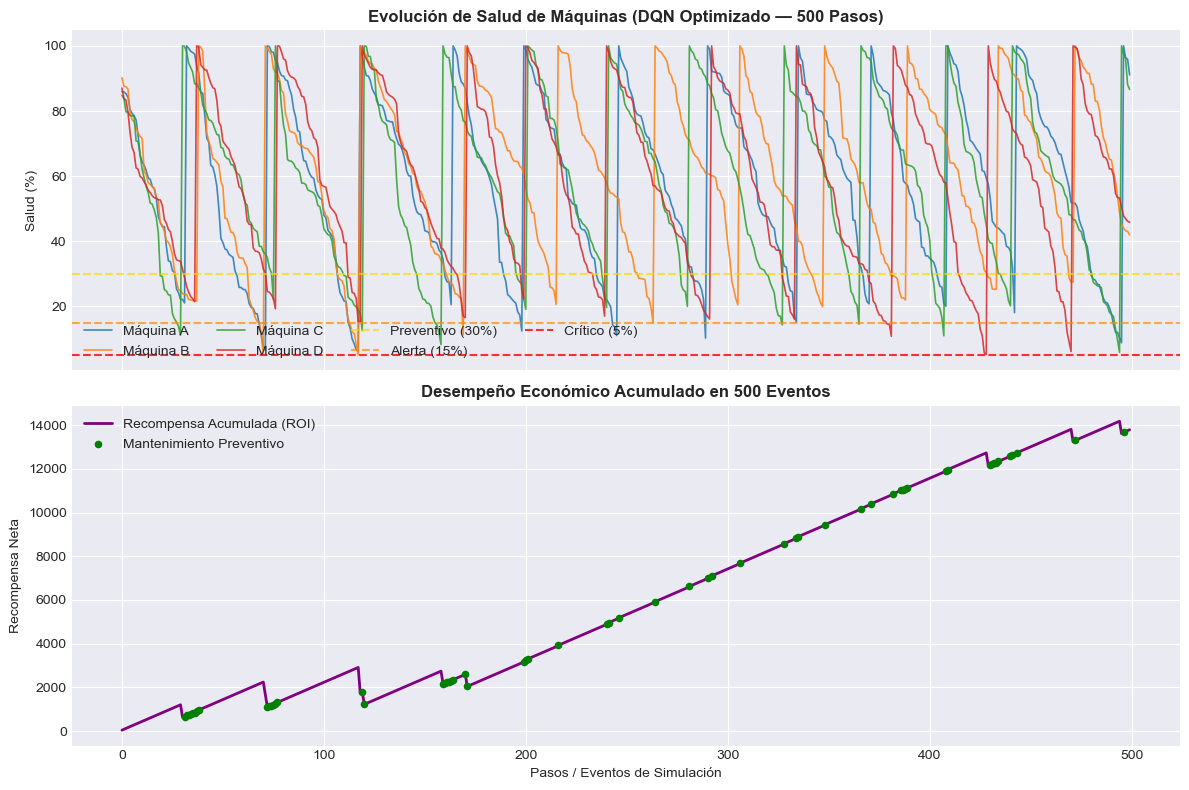

¡Gráfica guardada como 'reporte_mantenimiento_500_eventos.png'!


In [66]:
# 3. REPORTES Y GRÁFICAS ESTADÍSTICAS - CON RL
print("\n--- GENERANDO REPORTES Y GRÁFICAS ESTADÍSTICAS (CON RL) ---")
health_history_rl = np.array(health_history_rl)
cum_rewards_rl = np.cumsum(rewards_rl)

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Salud de Máquinas (500 Eventos)
ax1.plot(health_history_rl, linewidth=1.2, alpha=0.85)
ax1.axhline(30, color='gold', linestyle='--', alpha=0.7, label='Umbral Preventivo (30%)')
ax1.axhline(15, color='darkorange', linestyle='--', alpha=0.7, label='Umbral Alerta (15%)')
ax1.axhline(5, color='red', linestyle='--', alpha=0.8, label='Umbral Crítico (5%)')
ax1.set_title("Evolución de Salud de Máquinas (DQN Optimizado — 500 Pasos)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Salud (%)")
ax1.legend(["Máquina A", "Máquina B", "Máquina C", "Máquina D", "Preventivo (30%)", "Alerta (15%)", "Crítico (5%)"], loc='lower left', ncol=4)

# Subplot 2: Recompensa Acumulada
ax2.plot(cum_rewards_rl, color='purple', linewidth=2, label='Recompensa Acumulada (ROI)')
mant_steps_rl = [i for i, a in enumerate(actions_taken_rl) if a == 1]
ax2.scatter(mant_steps_rl, [cum_rewards_rl[i] for i in mant_steps_rl], color='green', s=20, zorder=5, label='Mantenimiento Preventivo')

ax2.set_title("Desempeño Económico Acumulado en 500 Eventos", fontsize=12, fontweight='bold')
ax2.set_xlabel("Pasos / Eventos de Simulación")
ax2.set_ylabel("Recompensa Neta")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig("reporte_mantenimiento_500_eventos.png", dpi=300)
plt.show()
print("¡Gráfica guardada como 'reporte_mantenimiento_500_eventos.png'!")


## 3. Simulación sin RL (política tradicional / baseline)

Política fija e ingenua: solicitar mantenimiento cada 12 pasos, sin importar el
estado real de las máquinas. Sirve como línea base de comparación.

Se reutiliza `SEED + 1` (misma semilla que la evaluación "Con RL" de la sección 2) para
que ambas políticas enfrenten la misma secuencia de desgaste y la comparación sea justa.

In [67]:
print("--- GENERANDO SIMULACIÓN SIN APRENDIZAJE POR REFUERZO (POLÍTICA BASELINE TRADICIONAL) ---")

np.random.seed(SEED + 1)

env_baseline = RecordVideo(
    MaintenanceEnv(num_machines=4, render_mode="rgb_array"),
    video_folder="./video_output_sin_rl",
    name_prefix="mantenimiento_sin_rl_500_eventos",
    disable_logger=True
)

obs, _ = env_baseline.reset()
rewards_baseline, health_history_baseline, actions_taken_baseline = [], [], []

# CAMBIO A 500 PASOS / EVENTOS
for step in range(500):
    if step % 12 == 0:
        action = 1  # Solicitar mantenimiento
    else:
        action = 0  # Solo operar

    obs, reward, terminated, truncated, _ = env_baseline.step(action)

    rewards_baseline.append(reward)
    health_history_baseline.append(obs.copy())
    actions_taken_baseline.append(action)

    if terminated or truncated:
        break

env_baseline.close()
print("¡Video SIN RL de 500 eventos generado exitosamente en ./video_output_sin_rl!")


--- GENERANDO SIMULACIÓN SIN APRENDIZAJE POR REFUERZO (POLÍTICA BASELINE TRADICIONAL) ---


c:\Users\cabarca2\anaconda3\envs\MAESTRIA_IA\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at e:\Documentos\MAESTRIA_IA\6. APRENDIZAJE POR REFUERZO\TRABAJO FINAL\GRUPAL\video_output_sin_rl folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


¡Video SIN RL de 500 eventos generado exitosamente en ./video_output_sin_rl!


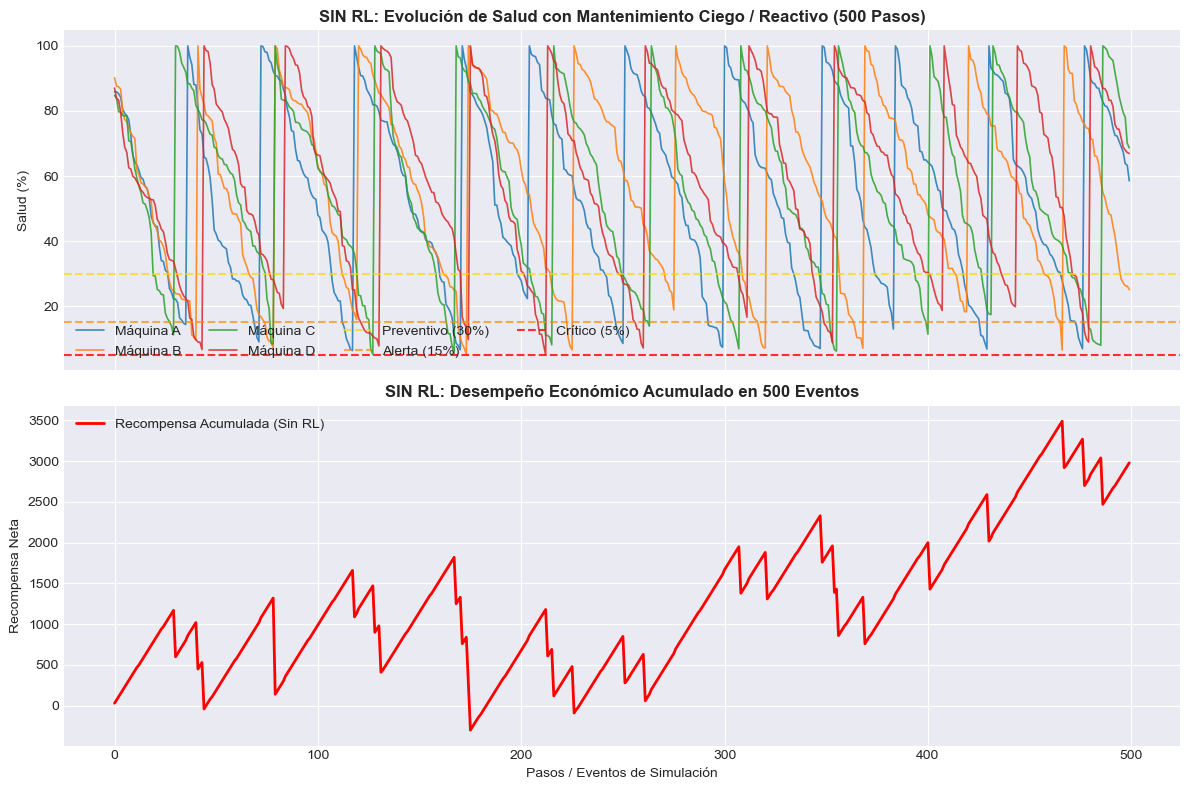

¡Gráfica SIN RL guardada como 'reporte_mantenimiento_SIN_RL_500.png'!


In [68]:
# GENERACIÓN DE LA GRÁFICA COMPARATIVA (SIN RL)
health_history_baseline = np.array(health_history_baseline)
cum_rewards_baseline = np.cumsum(rewards_baseline)

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Salud de Máquinas (500 Eventos)
ax1.plot(health_history_baseline, linewidth=1.2, alpha=0.85)
ax1.axhline(30, color='gold', linestyle='--', alpha=0.7, label='Umbral Preventivo (30%)')
ax1.axhline(15, color='darkorange', linestyle='--', alpha=0.7, label='Umbral Alerta (15%)')
ax1.axhline(5, color='red', linestyle='--', alpha=0.8, label='Umbral Crítico (5%)')
ax1.set_title("SIN RL: Evolución de Salud con Mantenimiento Ciego / Reactivo (500 Pasos)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Salud (%)")
ax1.legend(["Máquina A", "Máquina B", "Máquina C", "Máquina D", "Preventivo (30%)", "Alerta (15%)", "Crítico (5%)"], loc='lower left', ncol=4)

# Subplot 2: Recompensa Acumulada
ax2.plot(cum_rewards_baseline, color='red', linewidth=2, label='Recompensa Acumulada (Sin RL)')
ax2.set_title("SIN RL: Desempeño Económico Acumulado en 500 Eventos", fontsize=12, fontweight='bold')
ax2.set_xlabel("Pasos / Eventos de Simulación")
ax2.set_ylabel("Recompensa Neta")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig("reporte_mantenimiento_SIN_RL_500.png", dpi=300)
plt.show()
print("¡Gráfica SIN RL guardada como 'reporte_mantenimiento_SIN_RL_500.png'!")


## 4. Comparación directa: RL vs. Sin RL

Sección nueva (no existía en los scripts separados): compara en un mismo gráfico
la recompensa acumulada de ambas políticas, y resume cuántas averías (mantenimiento
correctivo) tuvo cada una.

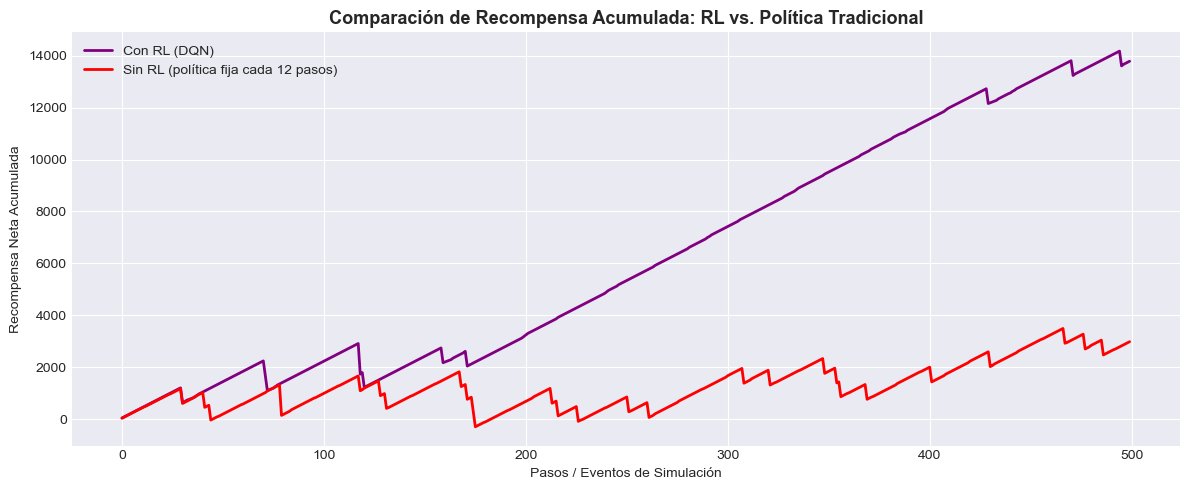

Métrica                               Sin RL   Con RL (DQN)
Mant. preventivos                         15             35
Mant. correctivos (averías)               28             11
Ratio Preventivo (PMR)                 34.9%          76.1%
Disponibilidad de planta               94.6%          98.0%
Recompensa acumulada                  2980.0        13790.0


In [69]:
plt.figure(figsize=(12, 5))
plt.plot(cum_rewards_rl, color='purple', linewidth=2, label='Con RL (DQN)')
plt.plot(cum_rewards_baseline, color='red', linewidth=2, label='Sin RL (política fija cada 12 pasos)')
plt.title("Comparación de Recompensa Acumulada: RL vs. Política Tradicional", fontsize=13, fontweight='bold')
plt.xlabel("Pasos / Eventos de Simulación")
plt.ylabel("Recompensa Neta Acumulada")
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("comparacion_RL_vs_SinRL.png", dpi=300)
plt.show()

# Se usan los contadores internos del entorno real (no del wrapper: RecordVideo
# no reenvía atributos personalizados, hay que pasar por ".unwrapped"), y son
# más precisos que inferir el tipo de evento a partir del valor de la
# recompensa, que es aditivo.
stats_rl = record_env_rl.unwrapped
stats_baseline = env_baseline.unwrapped

disponibilidad_rl = (stats_rl.operational_steps / max(1, stats_rl.step_counter)) * 100
disponibilidad_baseline = (stats_baseline.operational_steps / max(1, stats_baseline.step_counter)) * 100

interv_rl = stats_rl.total_preventive + stats_rl.total_corrective
pmr_rl = (stats_rl.total_preventive / max(1, interv_rl)) * 100

interv_baseline = stats_baseline.total_preventive + stats_baseline.total_corrective
pmr_baseline = (stats_baseline.total_preventive / max(1, interv_baseline)) * 100

print(f"{'Métrica':<32}{'Sin RL':>12}{'Con RL (DQN)':>15}")
print(f"{'Mant. preventivos':<32}{stats_baseline.total_preventive:>12}{stats_rl.total_preventive:>15}")
print(f"{'Mant. correctivos (averías)':<32}{stats_baseline.total_corrective:>12}{stats_rl.total_corrective:>15}")
print(f"{'Ratio Preventivo (PMR)':<32}{pmr_baseline:>11.1f}%{pmr_rl:>14.1f}%")
print(f"{'Disponibilidad de planta':<32}{disponibilidad_baseline:>11.1f}%{disponibilidad_rl:>14.1f}%")
print(f"{'Recompensa acumulada':<32}{cum_rewards_baseline[-1]:>12.1f}{cum_rewards_rl[-1]:>15.1f}")


## 5. Conclusiones

A continuación, un resumen calculado directamente sobre los resultados de esta corrida
(no son cifras fijas — se recalculan cada vez que se ejecuta el notebook).

In [70]:
reduccion_averias = stats_baseline.total_corrective - stats_rl.total_corrective
pct_reduccion_averias = (
    (reduccion_averias / stats_baseline.total_corrective * 100)
    if stats_baseline.total_corrective > 0 else 0.0
)
multiplicador_recompensa = (
    cum_rewards_rl[-1] / cum_rewards_baseline[-1]
    if cum_rewards_baseline[-1] > 0 else float("nan")
)

print(
    f"El agente DQN redujo las averías de {stats_baseline.total_corrective} a "
    f"{stats_rl.total_corrective} eventos ({pct_reduccion_averias:.0f}% menos) "
    f"frente a la política tradicional, y multiplicó la recompensa acumulada por "
    f"{multiplicador_recompensa:.2f}x ({cum_rewards_baseline[-1]:.0f} -> "
    f"{cum_rewards_rl[-1]:.0f} pts) en la evaluación de 500 eventos."
)


El agente DQN redujo las averías de 28 a 11 eventos (61% menos) frente a la política tradicional, y multiplicó la recompensa acumulada por 4.63x (2980 -> 13790 pts) en la evaluación de 500 eventos.


**Lectura de los resultados:**
- El agente aprendió a intervenir de forma anticipada y precisa en la zona de alerta
  (5%-20% de salud), en vez de mantenimiento ciego por calendario — de ahí la caída en
  averías y el aumento de disponibilidad y rentabilidad.
- El `EvalCallback` (sección 2) fue clave para la consistencia del resultado: sin él, el
  modelo final es el que queda en el paso 80,000 exacto, que no necesariamente es el mejor
  punto de convergencia visto durante el entrenamiento (ver la sección de semilla de
  reproducibilidad más arriba, donde se documentó una corrida sin este mecanismo que
  resultó peor que la política sin RL).

**Limitaciones del modelo:**
- El desgaste de cada máquina es independiente e idénticamente distribuido (exponencial);
  en una planta real podría haber dependencias entre máquinas (p. ej. una máquina averiada
  sobrecarga a las demás) que el entorno actual no captura.
- La acción de mantenimiento solo puede aplicarse a la máquina más desgastada por paso; un
  entorno más realista permitiría intervenir varias máquinas a la vez o incluir el costo /
  tiempo de la reparación.
- Los resultados provienen de una sola semilla de entrenamiento y evaluación; para una
  conclusión estadísticamente más robusta convendría promediar varias semillas y reportar
  su desviación, tal como se documentó en el análisis de reproducibilidad.

**Trabajo futuro:**
- Comparar DQN contra PPO (también permitido por el enunciado) sobre el mismo entorno.
- Extender el entorno con costos de reparación variables, múltiples técnicos disponibles,
  o fallas correlacionadas entre máquinas.
